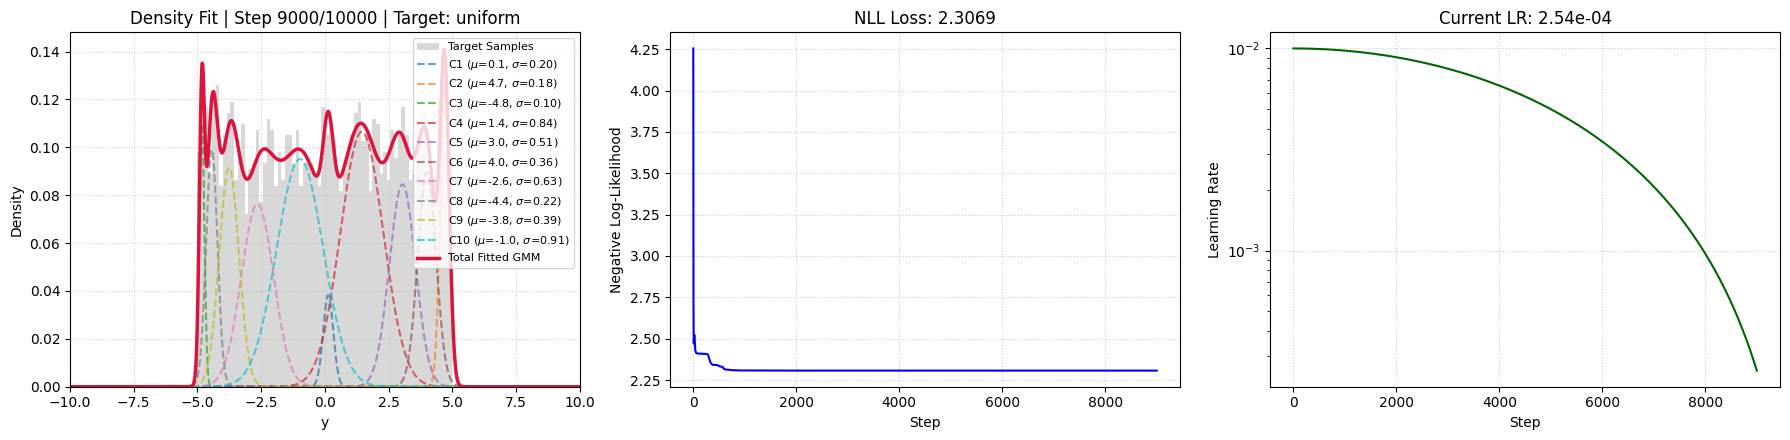

 94%|█████████▎| 9362/10000 [00:24<00:01, 375.71it/s]
/tmp/ipykernel_1057121/1634620371.py:132: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax1.plot(grid_np, component_pdfs[i], '--', alpha=0.7, label=f'C{i+1} ($\mu$={m[i]:.1f}, $\sigma$={s[i]:.2f})')
/tmp/ipykernel_1057121/1634620371.py:132: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax1.plot(grid_np, component_pdfs[i], '--', alpha=0.7, label=f'C{i+1} ($\mu$={m[i]:.1f}, $\sigma$={s[i]:.2f})')


KeyboardInterrupt: 

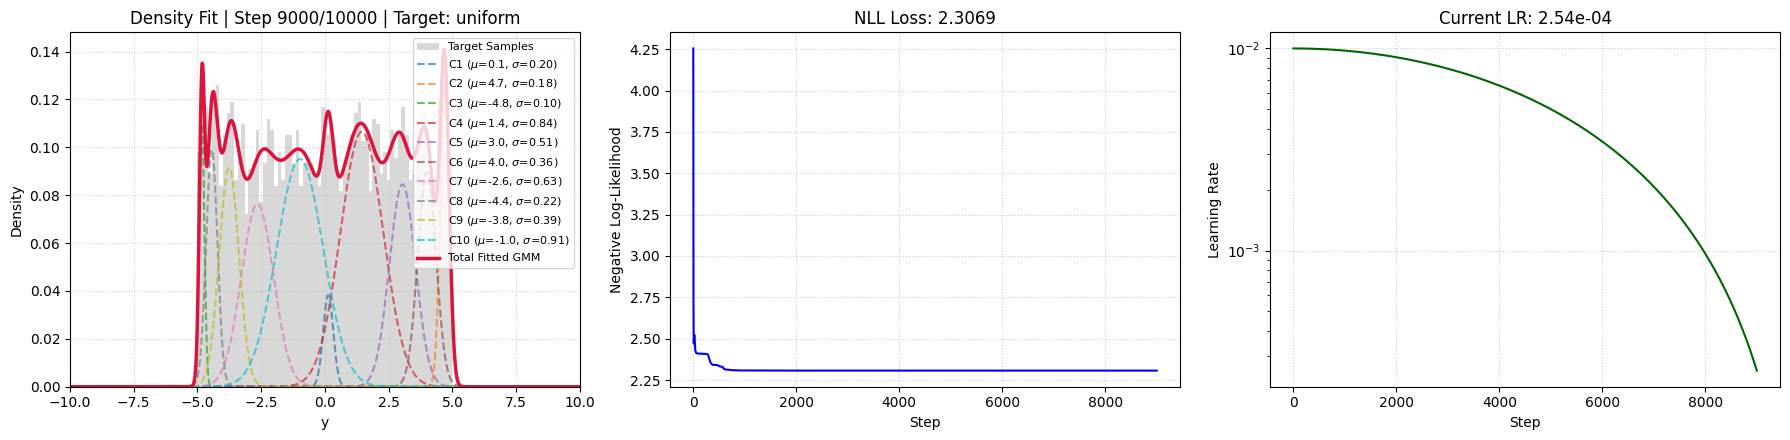

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
from tqdm import trange

# 1. Numerically Stable Continuous GMM Head
class FixedGMMHead(nn.Module):
    def __init__(self, input_dim=10, n_gaussians=5):
        super().__init__()
        self.n_gaussians = n_gaussians
        self.fc_means = nn.Linear(input_dim, n_gaussians)
        self.fc_log_stds = nn.Linear(input_dim, n_gaussians)
        self.fc_logits = nn.Linear(input_dim, n_gaussians)

        # Zero initialization for stds avoids initial extreme scaling
        nn.init.zeros_(self.fc_log_stds.weight)
        nn.init.zeros_(self.fc_log_stds.bias)

    def forward(self, x):
        means = self.fc_means(x)
        log_stds = torch.clamp(self.fc_log_stds(x), min=-4.0, max=3.0)
        log_weights = F.log_softmax(self.fc_logits(x), dim=-1)
        return means, log_stds, log_weights

    @staticmethod
    def log_likelihood(y, means, log_stds, log_weights):
        y = y.view(-1, 1)
        log_norm = -log_stds - 0.5 * np.log(2.0 * np.pi)
        log_kernel = -0.5 * torch.square((y - means) / torch.exp(log_stds))
        log_probs = log_norm + log_kernel + log_weights
        return torch.logsumexp(log_probs, dim=-1)

# 2. Expanded Complex Target Data Generator
def generate_complex_target_data(n_samples=4000, distribution="five_modes"):
    np.random.seed(42)
    
    if distribution == "five_modes":
        centers = [-5.0, -2.5, 0.0, 2.5, 5.0]
        stds = [0.3, 0.4, 0.2, 0.5, 0.3]
        weights = [0.15, 0.25, 0.20, 0.25, 0.15]
        components = np.random.choice(len(centers), size=n_samples, p=weights)
        y = np.array([np.random.normal(centers[c], stds[c]) for c in components])

    elif distribution == "heavy_tailed":
        main_mode = np.random.normal(loc=0.0, scale=0.8, size=int(n_samples * 0.7))
        heavy_tail = np.random.standard_cauchy(size=int(n_samples * 0.3)) * 1.2
        y = np.concatenate([main_mode, heavy_tail])
        y = np.clip(y, -10.0, 10.0)

    elif distribution == "uniform_clutter":
        c1 = np.random.normal(loc=-3.0, scale=0.5, size=int(n_samples * 0.4))
        c2 = np.random.normal(loc=3.0, scale=0.7, size=int(n_samples * 0.4))
        noise = np.random.uniform(low=-8.0, high=8.0, size=int(n_samples * 0.2))
        y = np.concatenate([c1, c2, noise])

    elif distribution == "nested_modes":
        wide_bg = np.random.normal(loc=0.0, scale=3.5, size=int(n_samples * 0.4))
        peak_left = np.random.normal(loc=-1.2, scale=0.2, size=int(n_samples * 0.3))
        peak_right = np.random.normal(loc=1.2, scale=0.2, size=int(n_samples * 0.3))
        y = np.concatenate([wide_bg, peak_left, peak_right])

    elif distribution == "log_skewed":
        comp1 = np.random.lognormal(mean=0.2, sigma=0.5, size=int(n_samples * 0.6)) - 4.0
        comp2 = np.random.normal(loc=3.0, scale=0.6, size=int(n_samples * 0.4))
        y = np.concatenate([comp1, comp2])
    elif distribution == "uniform":
        y = np.random.uniform(low=-5.0, high=5.0, size=n_samples)

    np.random.shuffle(y)
    return torch.tensor(y, dtype=torch.float32)

# 3. Robust Live Training & Visualization Loop with LR Scheduler
def fit_and_animate_gmm(n_gaussians=5, steps=20000, lr=1e-3, distribution="five_modes"):
    torch.manual_seed(42)
    
    y_data = generate_complex_target_data(n_samples=3000, distribution=distribution)
    x_context = torch.ones(len(y_data), 10)  # Fixed context embedding
    
    model = FixedGMMHead(input_dim=10, n_gaussians=n_gaussians)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Added Cosine Annealing Learning Rate Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps, eta_min=1e-5)

    y_grid = torch.linspace(-10.0, 10.0, 1000)
    loss_history = []
    lr_history = []

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4.5))

    plot_freq = 1000

    for step in trange(1, steps + 1):
        optimizer.zero_grad()
        means, log_stds, log_weights = model(x_context)
        loss = -model.log_likelihood(y_data, means, log_stds, log_weights).mean()
        loss.backward()
        optimizer.step()

        # Step Learning Rate Scheduler
        scheduler.step()

        loss_history.append(loss.item())
        lr_history.append(optimizer.param_groups[0]['lr'])

        # Update plot periodically or at final step
        if step % plot_freq == 0 or step == steps:
            with torch.no_grad():
                m = means[0].numpy()
                s = torch.exp(log_stds[0]).numpy()
                w = torch.exp(log_weights[0]).numpy()

                grid_np = y_grid.numpy()
                component_pdfs = [
                    w[i] * (1.0 / (s[i] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((grid_np - m[i]) / s[i]) ** 2)
                    for i in range(n_gaussians)
                ]
                total_pdf = np.sum(component_pdfs, axis=0)

            # Clear previous plots
            ax1.clear()
            ax2.clear()
            ax3.clear()

            # 1. Density Plot
            ax1.hist(y_data.numpy(), bins=70, density=True, alpha=0.3, color='gray', label='Target Samples')
            for i in range(n_gaussians):
                ax1.plot(grid_np, component_pdfs[i], '--', alpha=0.7, label=f'C{i+1} ($\mu$={m[i]:.1f}, $\sigma$={s[i]:.2f})')
            ax1.plot(grid_np, total_pdf, color='crimson', linewidth=2.5, label='Total Fitted GMM')
            ax1.set_title(f"Density Fit | Step {step}/{steps} | Target: {distribution}")
            ax1.set_xlim(-10, 10)
            ax1.set_xlabel("y")
            ax1.set_ylabel("Density")
            ax1.legend(loc="upper right", fontsize=8)
            ax1.grid(True, linestyle=':', alpha=0.6)

            # 2. Loss Curve Plot
            ax2.plot(loss_history, color='blue', linewidth=1.5)
            ax2.set_title(f"NLL Loss: {loss.item():.4f}")
            ax2.set_xlabel("Step")
            ax2.set_ylabel("Negative Log-Likelihood")
            ax2.grid(True, linestyle=':', alpha=0.6)

            # 3. Learning Rate Plot
            ax3.plot(lr_history, color='darkgreen', linewidth=1.5)
            ax3.set_title(f"Current LR: {scheduler.get_last_lr()[0]:.2e}")
            ax3.set_xlabel("Step")
            ax3.set_ylabel("Learning Rate")
            ax3.set_yscale("log")
            ax3.grid(True, linestyle=':', alpha=0.6)

            plt.tight_layout()
            clear_output(wait=True)
            display(fig)
            time.sleep(0.01)

    plt.close()

# Run optimization on complex targets
fit_and_animate_gmm(n_gaussians=10, steps=10000, lr=1e-2, distribution="uniform")